In [2]:
%load_ext autoreload
%autoreload 2
from data_handling import MassBalance, Albedo 
import xarray as xr 
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from scipy.stats import gaussian_kde as kde
import sys, os
from get_ddf import *
sys.path.append('/trace/home/cvwilson/research/PEBSI/shop/plotting/')
from plotting_fxns import * 

import socket
if 'trace' in socket.gethostname():
    base_fp = '/trace/group/rounce/cvwilson/Output/'
    home_fp = '/trace/home/cvwilson/research/'
else:
    base_fp = 'C:/Users/cvw30/Research/Output/'
    home_fp = 'C:/Users/cvw30/Research/'

colors = ['#63c4c7','#fcc02e','#4D559C','#60C252','#BF1F6A',
              '#F77808','#298282','#999999','#FF89B0','#427801']

coord_dict = {'wolverine':'60.5_-148.7',
                'kahiltna':'63.0_-151.2',
                'kennicott':'61.5_-143.1',
                'taku':'58.5_-134.3',
                'lemon_creek':'58.5_-134.3',
                'gulkana':'63.5_-145.6'}
site_dict = {'wolverine':['N','B','EC'],
                'kahiltna':['K53','K17b'], # took out K14k because it's too high --- wind redistribution probably crucial here
                'kennicott':['GTL','GTH','KC31'],
                'lemon_creek':['B','C','D'],
                'taku':['NWB1','MG1','TKG3'],
                'gulkana':['AU','B','D']
                }

lemon_creek B has biased mass balance using kp= 1.4230809067903878
Summer mass balance bias: 1.7807282326061413
Winter mass balance bias: -0.299503675843244
Albedo bias: 0.03179507832518432

lemon_creek C has biased mass balance using kp= 1.5168359512504206
Summer mass balance bias: 1.0874615016734013
Winter mass balance bias: -0.2357771515144763
Albedo bias: -0.021799080875407835



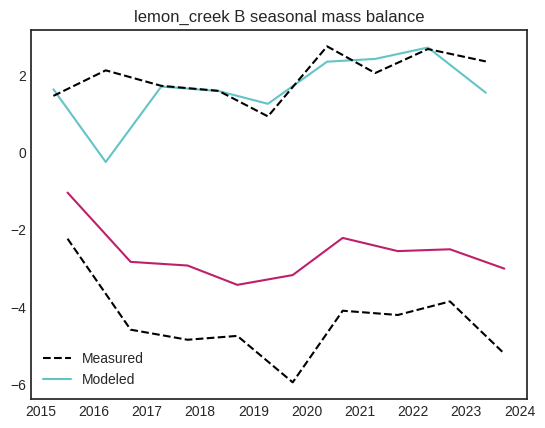

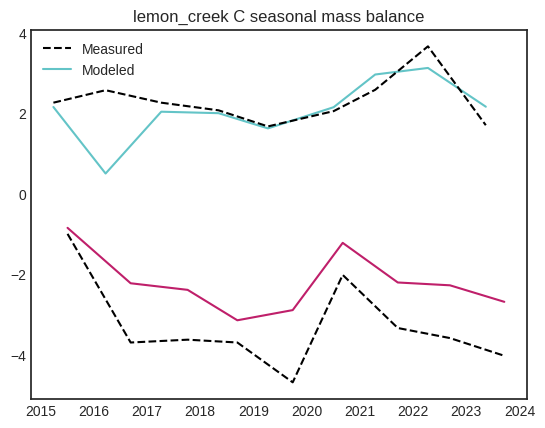

In [2]:
date = '03_19'
all_mod_albedo = []
all_meas_albedo = []
all_time_albedo = []
best_dict = {}
all_best = {}
for glacier in site_dict:
# for glacier in ['taku']: #
    best_dict[glacier] = {}
    all_best[glacier] = {}
    # for site in 'D': 
    for site in site_dict[glacier]:
        fp = base_fp # + f'{date}_{glacier}_{site}_0/'

        # if not os.path.exists(fp + 'missing.txt'):
        #     print(f'! no missing.txt in {glacier} {site}; simulations could be in progress !')
        #     continue
        fn = f'grid_{date}_setXX_run0_0.nc'

        min_error = np.inf
        by_params = {}
        for setno in [4]: # range(2, 30, 5):
            fn_set = fp + fn.replace('XX', str(setno))
            fn_set = fp + f'ddf/{glacier}{site}_2026_03_19_long_0.nc'
            if not os.path.exists(fn_set):
                continue

            mb_data = MassBalance(glacier, site, use='benchmark')
            albedo_data = Albedo(glacier, site)

            ds = xr.open_dataset(fn_set)
            mb_data.get_model_mb(ds)
            if mb_data.dataset == 'seasonal':
                mae_summer, mae_winter = mb_data.mae(True)
                mae_mb = mae_summer + mae_winter 
            else:
                mae_mb = mb_data.mae()
            
            albedo_data.get_model_albedo(ds)
            mae_albedo = albedo_data.mae()

            # if ds.attrs['ksp_BC'] not in by_params:
            #     by_params[ds.attrs['ksp_BC']] = {}
            # by_params[ds.attrs['ksp_BC']][ds.attrs['C1']] = albedo_data 

            error = mae_albedo # * 2 + mae_mb
            if error < min_error:
                min_error = error 
                best_set = (0.1, 4.33e-13, fn_set)
                best_ds = ds.copy(deep=True)

        mb_data = MassBalance(glacier, site, use='benchmark')
        albedo_data = Albedo(glacier, site)
        best_dict[glacier][site] = best_ds
        all_best[glacier][site] = {'ksp_BC':best_set[0], 'C1':best_set[1]}

        # parse model run
        albedo_data.get_model_albedo(best_ds)
        mb_data.get_model_mb(best_ds)
        
        if mb_data.dataset == 'seasonal':
            me_summer, me_winter = mb_data.bias(True)
            if np.abs(me_summer) > 1 or np.abs(me_winter) > 1:
                print(best_ds.attrs['glacier'], best_ds.attrs['site'],'has biased mass balance using kp=',best_ds.attrs['kp'])
                print('Summer mass balance bias:',me_summer)
                print('Winter mass balance bias:',me_winter)
                print('Albedo bias:',albedo_data.bias())
                print()
                mb_data.plot_mb()
        else:
            if np.abs(mb_data.mae()) > 1:
                print(best_ds.attrs['glacier'], best_ds.attrs['site'],'has biased mass balance using kp=',best_ds.attrs['kp'])
                print('Annual mass balance bias:',mb_data.mae())
                print('Albedo bias:',albedo_data.bias())
                print()
                mb_data.plot_mb()
               

        # plot
        # mb_data.plot_mb()
        # albedo_data.plot_timeseries()

        for mod, meas, t in zip(albedo_data.mod, albedo_data.meas, albedo_data.time):
            all_mod_albedo.append(mod)
            all_meas_albedo.append(meas)
            all_time_albedo.append(t)

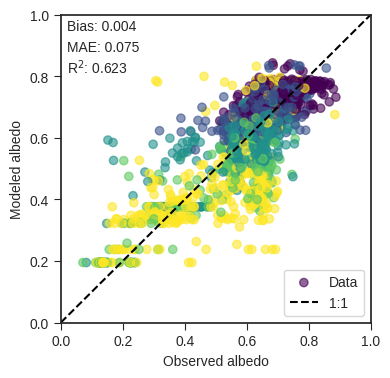

In [13]:
fig, ax = plt.subplots(figsize=(4, 4))
cmap = plt.get_cmap('viridis')
norm = mpl.colors.Normalize(vmin=4, vmax=8)

ax.scatter(all_meas_albedo, all_mod_albedo, alpha=0.6, label='Data', c=cmap(norm(pd.to_datetime(all_time_albedo).month)))
ax.plot([0,1],[0,1],'k--',label='1:1')

meas = np.array(all_meas_albedo).ravel()
mod = np.array(all_mod_albedo).ravel()
bias = np.nanmean(meas - mod)
mae = np.nanmean(np.abs(meas - mod))
r2 = 1 - np.sum(np.square(meas - mod)) / np.sum(np.square(meas - np.mean(meas)))
ax.text(0.02, 0.95, f'Bias: {bias:.3f}', transform=ax.transAxes)
ax.text(0.02, 0.88, f'MAE: {mae:.3f}', transform=ax.transAxes)
ax.text(0.02, 0.81, f'R$^2$: {r2:.3f}', transform=ax.transAxes)

ax.legend(frameon=True)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.tick_params(length=5)
ax.set_ylabel('Modeled albedo')
ax.set_xlabel('Observed albedo')
plt.show()

In [5]:
for glacier in site_dict:
    coords = coord_dict[glacier]
    ds_bcd = xr.open_dataset(f'/trace/group/rounce/cvwilson/climate_data/MERRA2/{coords}/BCDP002_{coords}.nc')
    ds_bcw = xr.open_dataset(f'/trace/group/rounce/cvwilson/climate_data/MERRA2/{coords}/BCWT002_{coords}.nc')
    ds_bc = ds_bcd['BCDP002'] + ds_bcw['BCWT002']
    ds_sw = xr.open_dataset(f'/trace/group/rounce/cvwilson/climate_data/MERRA2/{coords}/SWGDN_{coords}.nc')
    ds_bc = ds_bc.assign_coords({'time':ds_bc.time.values - pd.Timedelta(hours=8)})
    ds_sw = ds_sw.assign_coords({'time':ds_sw.time.values - pd.Timedelta(hours=8)})

    for site in site_dict[glacier]:
        ds = xr.open_dataset(base_fp+f'ddf/{glacier}{site}_2026_03_19_long_0.nc')
        out_daily = base_fp + f'ddf/{glacier}{site}_df_daily.csv'
        out_hourly = base_fp + f'ddf/{glacier}{site}_df_hourly.csv'
        get_daily_df(ds, ds_bc, ds_sw, output_fn=out_daily, n_rolling_bc=5, n_rolling_pdds=1)
        get_hourly_df(ds, ds_bc, ds_sw, output_fn=out_hourly, n_rolling_bc=5)

Saved wolverine N
Saved wolverine B
Saved wolverine EC
Saved kahiltna K53
Saved kahiltna K17b
Saved kennicott GTL
Saved kennicott GTH
Saved kennicott KC31
Saved lemon_creek B
Saved lemon_creek C
Saved lemon_creek D
Saved taku NWB1
Saved taku MG1
Saved taku TKG3
Saved gulkana AU
Saved gulkana B
Saved gulkana D


In [25]:
coords = '63.5_-145.6'
df_before = pd.read_csv(base_fp + 'ddf/gulkanaD_df_hourly.csv')
ds = xr.open_dataset(base_fp + 'ddf/gulkanaD_2026_03_19_long_0.nc')
ds_bcd = xr.open_dataset(f'/trace/group/rounce/cvwilson/climate_data/MERRA2/{coords}/BCDP002_{coords}.nc')
ds_bcw = xr.open_dataset(f'/trace/group/rounce/cvwilson/climate_data/MERRA2/{coords}/BCWT002_{coords}.nc')
ds_bc = ds_bcd['BCDP002'] + ds_bcw['BCWT002']
ds_sw = xr.open_dataset(f'/trace/group/rounce/cvwilson/climate_data/MERRA2/{coords}/SWGDN_{coords}.nc')
ds_bc = ds_bc.assign_coords({'time':ds_bc.time.values - pd.Timedelta(hours=8)})
ds_sw = ds_sw.assign_coords({'time':ds_sw.time.values - pd.Timedelta(hours=8)})
ds_new = get_hourly_df(ds, ds_bc, ds_sw)

In [16]:
import pandas as pd 
df = pd.read_csv('/trace/group/rounce/cvwilson/rs/sar/Vertex_Path_Frame_info.csv', dtype=str, converters={'Path': lambda x: x})
df["Path"] = df["Path"].apply(lambda x: f"{int(x):03d}")
# print(df.iloc[0]['Path'])
print(df.loc[df['Path'] == '094'])

   Path Frame  Direction
26  094   205  Ascending
27  094   200  Ascending
28  094   194  Ascending


/tmp/ipykernel_2286486/1047193030.py:2: ParserWarning: Both a converter and dtype were specified for column Path - only the converter will be used.
  df = pd.read_csv('/trace/group/rounce/cvwilson/rs/sar/Vertex_Path_Frame_info.csv', dtype=str, converters={'Path': lambda x: x})


In [6]:
all_dfs = {'hourly':None, 'daily':None}
for glacier in site_dict:
    for site in site_dict[glacier]:
        for time_res in all_dfs:
            out = base_fp+f'ddf/{glacier}{site}_df_{time_res}.csv'
            df = pd.read_csv(out)
            if 'accum_1d_rolling' in df.columns:
                df = df.rename(columns={'accum_1d_rolling','accum'})
            df['glacier'] = [glacier] * len(df.index)
            df['glaciersite'] = [glacier + site] * len(df.index)
            if all_dfs[time_res] is not None:
                all_dfs[time_res] = pd.concat([all_dfs[time_res], df])
            else:
                all_dfs[time_res] = df
all_dfs['daily'].to_csv(base_fp+'ddf/all_daily_df.csv')
all_dfs['hourly'].to_csv(base_fp+'ddf/all_hourly_df.csv')

In [ ]:
#######################################################################################